In [2]:
import sys, os

sys.path.append("../")

from vi_rnn.saving import load_model
import torch

from vi_rnn.saving import load_model
import matplotlib.pyplot as plt
from vi_rnn.generate import generate


# Load model
name = "rbm_run_3_5_EEG_low_rank_affine_dim_z_3_date_2026_03_22_T_19_35_50"

vae, training_params, task_params = load_model(
    "../models/sweep_eeg/" + name, load_encoder=False, backward_compat=True
)

no out nonlinearity found, setting to identity
using uniform init
Initialising VAE without encoder


In [3]:
import mne
import numpy as np
from mne.io import read_raw_edf, concatenate_raws
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from mne.decoding import CSP

# 1. LOAD AND CONCATENATE
data_path = 'files/S001/'
raw_fnames = [data_path + f for f in ['S001R03.edf', 'S001R05.edf', 'S001R07.edf', 'S001R09.edf', 'S001R11.edf','S001R13.edf' ]]
raw = concatenate_raws([read_raw_edf(f, preload=True) for f in raw_fnames])

# # 2. FREQUENCY FILTERING (Crucial for Motor Imagery)
# Isolating 8-30Hz (Mu and Beta bands)
raw.set_eeg_reference('average', projection=False)
raw_not_filtered = raw.copy()

raw.filter(8., 30., fir_design='firwin', skip_by_annotation='edge')


# # 2. WIDER FREQUENCY FILTERING
# # 0.5Hz removes the drift; 40Hz keeps the brain signal but removes powerline noise
# raw.filter(0.5, 40.0, fir_design='firwin', skip_by_annotation='edge')


# 1. UPDATED FILTER (The Middle Ground)
# raw.filter(4., 38., fir_design='firwin', skip_by_annotation='edge')
# raw.set_eeg_reference('average', projection=False)


# 3. EPOCHING
mapping = {'T0': 'Rest', 'T1': 'Task', 'T2': 'Task'}
raw.annotations.rename(mapping)
events, event_id = mne.events_from_annotations(raw, regexp='Rest|Task', 
                                              event_id={'Rest': 0, 'Task': 1})

# 4. EPOCHING 
# Set baseline=None because we handle scaling manually in the next step
epochs = mne.Epochs(raw, events, event_id=event_id, 
                    tmin=0, tmax=4.0, baseline=None, 
                    preload=True, proj=False, verbose=False)


epochs_non_filtered = mne.Epochs(raw_not_filtered, events, event_id=event_id,
                    tmin=0, tmax=4.0, baseline=None,
                    preload=True, proj=False, verbose=False)

X_raw_data = epochs.get_data(copy=True) 
y_labels = epochs.events[:, -1]

X_raw_data_non_filtered = epochs_non_filtered.get_data(copy=True) 


# 5. TRIAL-WISE Z-SCORING (Manual Baseline/Scaling)
# This replaces the need for MNE's baseline parameter
X_real = np.zeros_like(X_raw_data)
X_gen = np.zeros_like(X_raw_data)
for i in range(X_raw_data.shape[0]):
    trial = X_raw_data[i]
    # Standardize: Mean 0, Std 1 for this specific trial
    # This removes DC offsets and scales amplitude differences
    
    trial_z = (trial - np.mean(trial)) / np.std(trial)
    
    X_real[i] = trial_z
    
    """ get the corresponding generated data for this trial"""
    trial_non_filtered = X_raw_data_non_filtered[i]
    trial_non_filtered_z = (trial_non_filtered - np.mean(trial_non_filtered)) / np.std(trial_non_filtered)
    with torch.no_grad():
        # generate data using our fit model
        Z, _, data_gen, rates_gen = generate(
            vae,
            u=None,
            x=torch.from_numpy(trial_non_filtered_z.astype(np.float32)),
            initial_state="posterior_mean",
            k=1,
        )
    data_gen_np = (
    data_gen.squeeze()        # -> (64, n_times)
     .numpy()
    )
    X_gen[i] = data_gen_np

# 5. AUGMENTATION (Split 4s -> 1s)
n_trials, n_channels, n_times = X_real.shape
n_splits = 2
samples_per_split = n_times // n_splits


# 6. FILTER THE GENERATED DATA (Post-Generation)
# We use mne.filter.filter_data because X_gen is a NumPy array
print("Filtering generated data...")
X_gen_filtered = mne.filter.filter_data(
    X_gen.astype('float64'), 
    sfreq=160, 
    l_freq=8.0, 
    h_freq=30.0, 
    fir_design='firwin',
    verbose=False
)

# 7. AUGMENTATION (Using the filtered Gen data)
X_real_aug, X_gen_aug, y_aug, groups_aug = [], [], [], []

for i in range(n_trials):
    for s in range(n_splits):
        start = s * samples_per_split
        # Real is already filtered from the Epochs object
        X_real_aug.append(X_real[i, :, start:start + samples_per_split])
        # Use the NEW filtered generated data
        X_gen_aug.append(X_gen_filtered[i, :, start:start + samples_per_split])
        
        y_aug.append(y_labels[i])
        groups_aug.append(i)

X_real_aug = np.array(X_real_aug)
X_gen_aug = np.array(X_gen_aug)
y_aug = np.array(y_aug)
groups_aug = np.array(groups_aug)


Extracting EDF parameters from files/S001/S001R03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from files/S001/S001R05.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from files/S001/S001R07.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from files/S001/S001R09.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from files/S001/S001R11.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from files/S001/S001R13.edf...
Setting channel info structure...
Creating raw.info s

In [4]:
"""decode svm real """
# 6. FINAL DECODING (CSP + SVM)
pipe = Pipeline([
    ('csp', CSP(n_components=6, reg='ledoit_wolf', log=True)), # Ledoit-Wolf is more robust
    ('scaler', StandardScaler()), 
    ('svm', SVC(kernel='rbf', C=1.5, gamma='auto'))
])

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(pipe, X_real_aug, y_aug, cv=gkf, groups=groups_aug)

print(f"Real data Accuracy: {scores.mean():.2f} (+/- {scores.std():.2f})")

Computing rank from data with rank=None
    Using tolerance 21 (2.2e-16 eps * 64 dim * 1.5e+15  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 21 (2.2e-16 eps * 64 dim * 1.5e+15  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 21 (

In [5]:
"""decode svm gen """
# 6. FINAL DECODING (CSP + SVM)
pipe = Pipeline([
    ('csp', CSP(n_components=6, reg='ledoit_wolf', log=True)), # Ledoit-Wolf is more robust
    ('scaler', StandardScaler()), 
    ('svm', SVC(kernel='rbf', C=1.5, gamma='auto'))
])

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(pipe, X_gen_aug, y_aug, cv=gkf, groups=groups_aug)

print(f"Generated data Accuracy: {scores.mean():.2f} (+/- {scores.std():.2f})")

Computing rank from data with rank=None
    Using tolerance 12 (2.2e-16 eps * 64 dim * 8.3e+14  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 12 (2.2e-16 eps * 64 dim * 8.3e+14  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 12 (2.2e-16 eps * 64 dim * 8.3e+14  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using LEDOIT_WOL

In [6]:
"""decode Riemannian real """

from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace # Try with and without the underscore if one fails
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# 1. Pipeline: Covariance -> Tangent Space -> Classifier
# This handles the geometry of the 64 channels perfectly
pipe_riemann = Pipeline([
    ('cov', Covariances(estimator='lwf')), # Estimates the 'connectivity'
    ('ts', TangentSpace(metric='riemann')), # Projects to a flat vector space
    ('svm', SVC(kernel='linear', C=1.0))    # Linear SVM is best for Tangent Space
])

# 2. Evaluate
# Use the same augmented data and groups as before
scores_riemann = cross_val_score(pipe_riemann, X_real_aug, y_aug, cv=gkf, groups=groups_aug)

print(f"Riemannian Accuracy (Real): {scores_riemann.mean():.2f} (+/- {scores_riemann.std():.2f})")

Riemannian Accuracy (Real): 0.70 (+/- 0.07)


In [7]:
"""decode Riemannian generated """

from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace # Try with and without the underscore if one fails
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# 1. Pipeline: Covariance -> Tangent Space -> Classifier
# This handles the geometry of the 64 channels perfectly
pipe_riemann = Pipeline([
    ('cov', Covariances(estimator='lwf')), # Estimates the 'connectivity'
    ('ts', TangentSpace(metric='riemann')), # Projects to a flat vector space
    ('svm', SVC(kernel='linear', C=1.0))    # Linear SVM is best for Tangent Space
])

# 2. Evaluate
# Use the same augmented data and groups as before
scores_riemann = cross_val_score(pipe_riemann, X_gen_aug, y_aug, cv=gkf, groups=groups_aug)

print(f"Riemannian Accuracy (Generated): {scores_riemann.mean():.2f} (+/- {scores_riemann.std():.2f})")

Riemannian Accuracy (Generated): 0.49 (+/- 0.07)


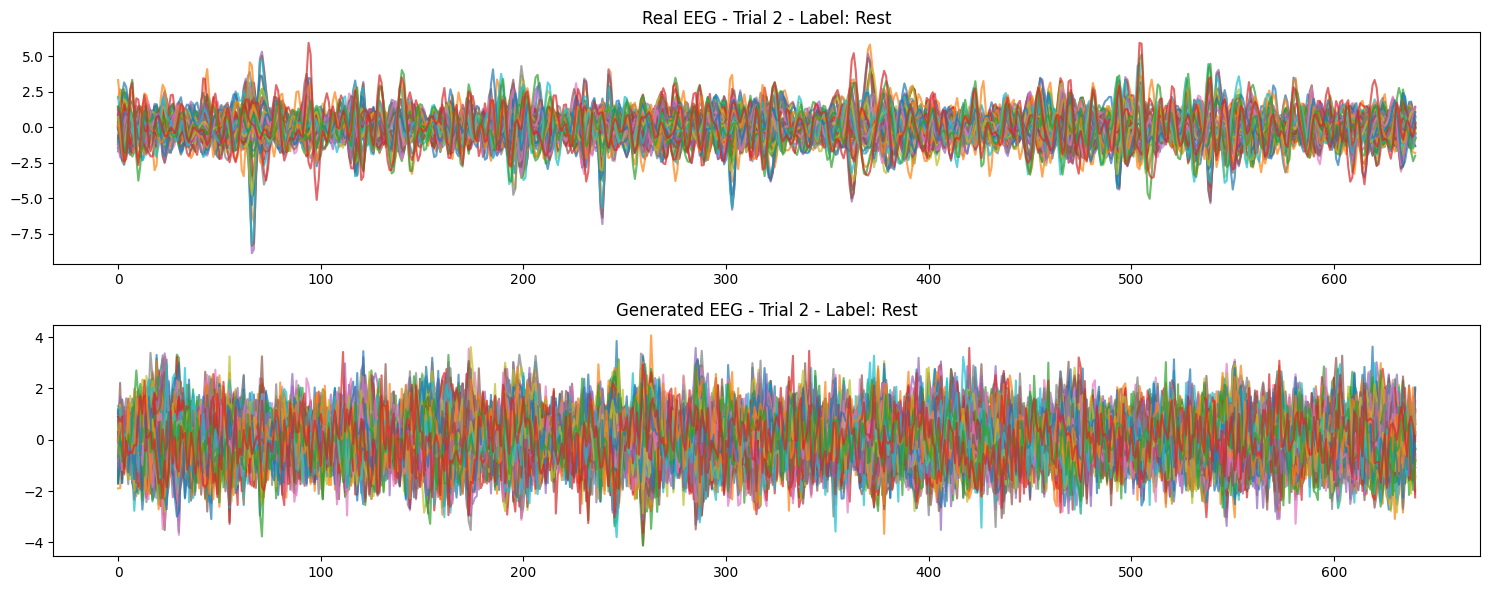

In [8]:
"""plot real and gen data for one trial"""
trial_idx = 2
plt.figure(figsize=(15, 6))
plt.subplot(2, 1, 1)
plt.title(f"Real EEG - Trial {trial_idx} - Label: {'Task' if y_labels[trial_idx] == 1 else 'Rest'}")
plt.plot(X_real[trial_idx].T, alpha=0.7)
plt.subplot(2, 1, 2)
plt.title(f"Generated EEG - Trial {trial_idx} - Label: {'Task' if y_labels[trial_idx] == 1 else 'Rest'}")
plt.plot(X_gen[trial_idx].T, alpha=0.7)
plt.tight_layout()
plt.show()

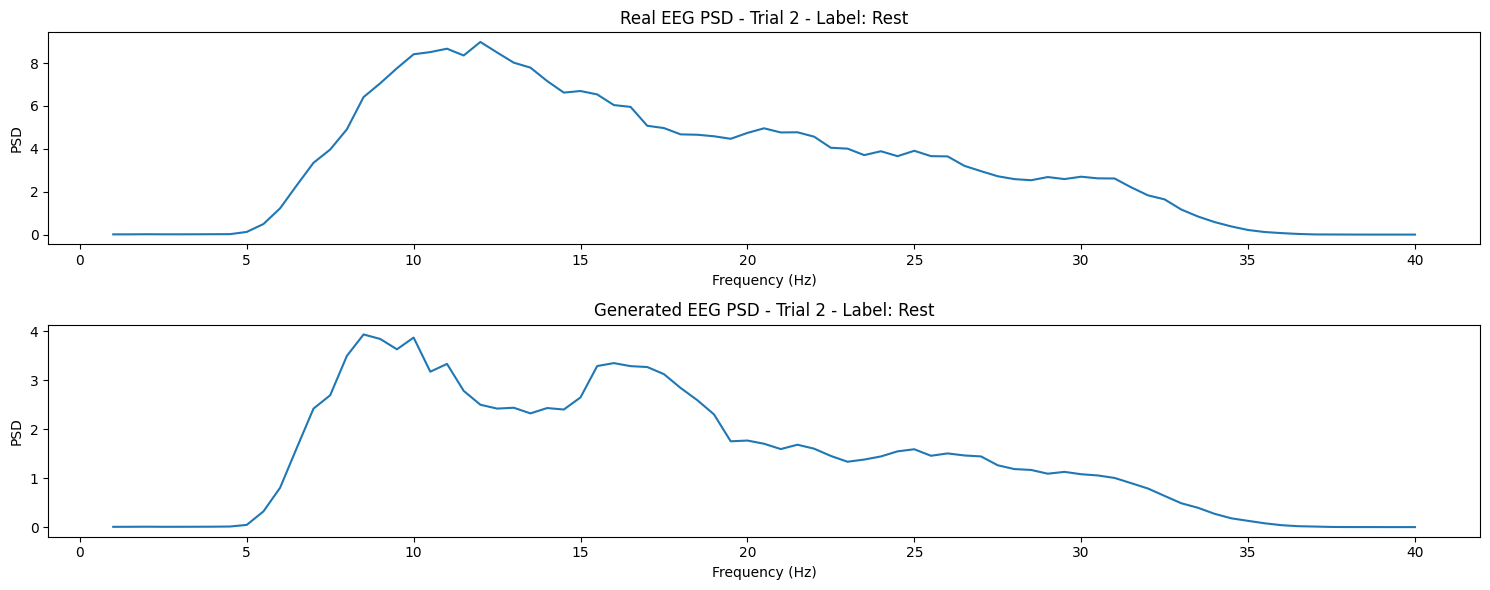

In [9]:
import matplotlib.pyplot as plt
import mne
import numpy as np

trial_idx = 2
sfreq = raw.info['sfreq']

plt.figure(figsize=(15, 6))

# --- REAL ---
plt.subplot(2, 1, 1)
plt.title(f"Real EEG PSD - Trial {trial_idx} - Label: {'Task' if y_labels[trial_idx] == 1 else 'Rest'}")

psd_real, freqs = mne.time_frequency.psd_array_multitaper(
    X_real_aug[trial_idx], sfreq=sfreq, fmin=1, fmax=40, verbose=False
)

plt.plot(freqs, psd_real.mean(axis=0))  # average over channels
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")

# --- GENERATED ---
plt.subplot(2, 1, 2)
plt.title(f"Generated EEG PSD - Trial {trial_idx} - Label: {'Task' if y_labels[trial_idx] == 1 else 'Rest'}")

psd_gen, freqs = mne.time_frequency.psd_array_multitaper(
    X_gen_aug[trial_idx], sfreq=sfreq, fmin=1, fmax=40, verbose=False
)

plt.plot(freqs, psd_gen.mean(axis=0))
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")

plt.tight_layout()
plt.show()